In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bootstrap

# T5

## f)

In [4]:
θ = 5

samples = np.random.uniform(θ, 2 * θ, 100)
print (f'Выборка: {samples}')

Выборка: [6.24573405 7.19156786 7.24740643 9.57803172 5.53101567 9.78165603
 6.73420286 7.91197948 7.77992427 6.82673071 6.62246218 6.05450651
 6.96205832 9.43009296 6.04480217 7.7772421  9.42348149 8.61932412
 8.43282166 5.62334751 8.36536045 5.99807243 6.84437533 8.18742187
 9.95697458 7.37972544 8.80535676 5.11913729 5.19557938 7.31410493
 7.69008887 7.28081273 6.50499757 5.87126236 7.77681885 7.35344098
 6.31946248 8.63244168 9.20488067 5.58442484 6.47713306 9.78164057
 7.77073454 8.4151705  8.02477713 7.94300893 7.38982047 7.79624607
 7.04857591 8.99916038 5.61468893 9.25571467 7.12681498 9.06556602
 8.23226443 7.98050851 6.26971206 6.5931179  6.54651028 5.46620958
 7.0528607  5.86579962 6.55821149 7.78550234 8.13345857 5.80772978
 9.34657875 7.73388972 7.96070435 9.37384571 8.27359647 6.01018787
 5.26281934 9.98827416 9.29522003 7.82531334 8.63067877 8.09239137
 6.51166642 8.51909526 7.11005246 7.30210308 7.88334043 5.56803702
 7.40399745 7.68789989 8.61299016 8.28147512 8.370819

In [5]:
left_value_exact = np.max(samples) / (((1 + 0.95)/2) ** (1/len(samples)) + 1)
right_value_exact = np.max(samples) / (((1 - 0.95)/2) ** (1/len(samples)) + 1)

print (f'Точный доверительный интервал:')
print (f'[{left_value_exact}, {right_value_exact}]')

Точный доверительный интервал:
[4.9958542532081855, 5.087345323852336]


In [6]:
first_moment = np.mean(samples)
second_moment = np.mean(samples ** 2)
t1 = -1.96
t2 = 1.96

left_value_as = 2/3 * first_moment - (3/2 * np.sqrt(np.var(samples))) / np.sqrt(len(samples)) * t2 
right_value_as =  2/3 * first_moment - (3/2 * np.sqrt(np.var(samples))) / np.sqrt(len(samples)) * t1

print (f'Ассимтотический доверительный интервал:')
print (f'[{left_value_as}, {right_value_as}]')

Ассимтотический доверительный интервал:
[4.649125722485354, 5.391211500912594]


## g)

In [7]:
res_bootstrap = bootstrap((samples,), lambda x: (2/3) * np.mean(x), confidence_level=0.95, n_resamples=1000000)

print (f'bootstap доверительный интервал:')
print (f'[{res_bootstrap.confidence_interval.low}, {res_bootstrap.confidence_interval.high}]')

bootstap доверительный интервал:
[4.855673333239642, 5.185463225396791]


## h)

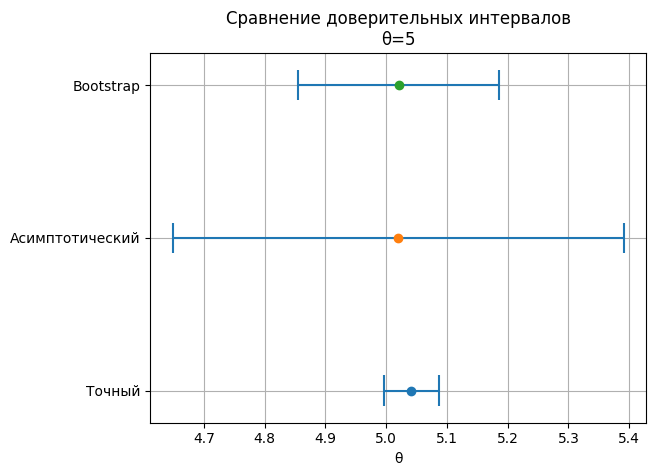

In [8]:
intervals = [
    (left_value_exact, right_value_exact),
    (left_value_as, right_value_as),
    (res_bootstrap.confidence_interval.low, res_bootstrap.confidence_interval.high),
]

labels = [
    "Точный",
    "Асимптотический",
    "Bootstrap"
]

centers = [(l + r) / 2 for l, r in intervals]

plt.figure()

for i, ((l, r), c) in enumerate(zip(intervals, centers)):
    plt.hlines(y=i, xmin=l, xmax=r)
    plt.vlines([l, r], i-0.1, i+0.1)
    plt.plot(c, i, 'o')

plt.yticks(range(len(intervals)), labels)
plt.xlabel("θ")
plt.title("Сравнение доверительных интервалов\nθ=5")

plt.grid()
plt.show()

# T6

## d)

In [9]:
θ = 5
samples_pareto = 1 + np.random.pareto(θ - 1, 100)

print (samples_pareto)

[1.57067978 1.04483664 1.00146404 1.00544683 1.07911142 1.39820989
 1.16402805 1.06428316 1.0747986  1.0067956  1.34860379 1.18372739
 1.5512178  1.35354185 1.0079468  1.09522223 1.1143415  1.20188499
 1.01890373 1.22034029 1.24085942 3.36966611 1.71449156 1.02291056
 1.06282586 1.18695408 1.00513837 1.12402555 1.17299506 1.3222644
 1.20532119 1.34475538 1.22126252 1.13380353 1.05100238 1.32383663
 1.6623451  1.08689763 1.02935083 1.13181819 1.39273518 1.46479063
 1.09831319 1.17260907 1.18145437 1.16506495 1.09086565 1.05594694
 1.05024234 1.02323855 1.02773591 1.07354587 1.27885492 1.3500296
 1.13654622 1.04509859 1.12448546 1.58168488 1.2683629  1.30625166
 1.62658413 1.11680373 1.21016449 1.35640359 1.02854809 2.10754395
 1.92150041 1.05793012 7.43657639 1.12279766 1.05350835 1.08956215
 1.75223574 1.07844752 1.09594357 1.53800469 1.11995079 1.18012584
 1.17965464 1.99449531 1.20627642 1.32067773 1.83686956 1.0244914
 1.02257431 1.92727859 2.21842592 1.58958479 1.02654668 1.4188366

In [10]:
sorted_samples_par = np.sort(samples_pareto)

print (f'Точный доверительный интервал для медианы:')
print (f'[{sorted_samples_par[40]}, {sorted_samples_par[60]}]')

Точный доверительный интервал для медианы:
[1.1244854552789996, 1.2354711686778193]


In [11]:
θ_wave = len(samples_pareto) / np.sum(np.log(samples_pareto)) + 1
t1 = -1.96
t2 = 1.96

left_value_par_as = θ_wave - t1 * (1 - θ_wave) / np.sqrt(len(samples_pareto))
right_value_par_as = θ_wave - t2 * (1 - θ_wave) / np.sqrt(len(samples_pareto))

print (f'Асимптотический доверительный интервал для θ:')
print (f'[{left_value_par_as}, {right_value_par_as}]')

Асимптотический доверительный интервал для θ:
[4.291068793360361, 5.895669498580836]


## t)

In [12]:
res_bootstrap_par = bootstrap((samples,), lambda x: len(samples_pareto) / np.sum(np.log(x)) + 1, confidence_level=0.95, n_resamples=1000000)

print (f'непараметрический bootstap доверительный интервал:')
print (f'[{res_bootstrap_par.confidence_interval.low}, {res_bootstrap_par.confidence_interval.high}]')

непараметрический bootstap доверительный интервал:
[1.4908030900414382, 1.5075295889946736]


In [ ]:
def pareto_sample(θ, n):
    return 1 + np.random.pareto(θ - 1, n)

def theta_stat(x):
    return len(x)/np.sum(np.log(x)) + 1

B = 5000000
theta_star = [theta_stat(pareto_sample(theta_stat(samples_pareto), len(samples_pareto))) for _ in range(B)]

ci = np.percentile(theta_star, [2.5, 97.5])
print(f"параметрический bootstrap:")
print(f'{ci}')

параметрический bootstrap:
[4.39653143 6.03135807]


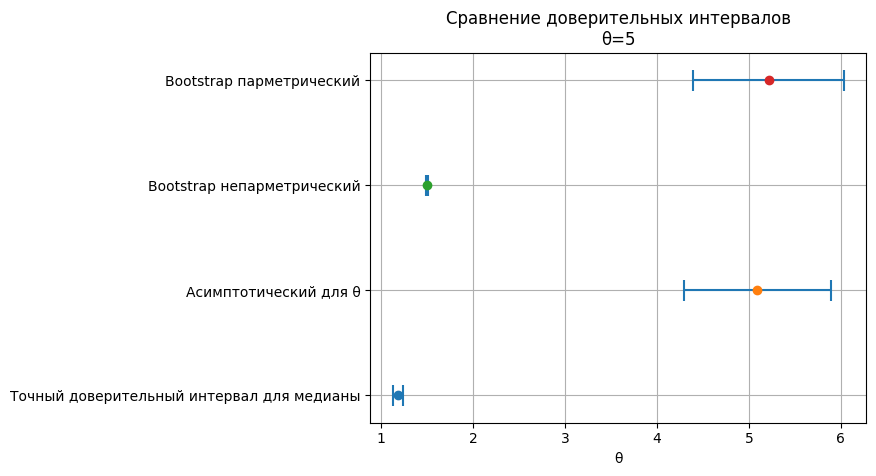

In [31]:
intervals = [
    (sorted_samples_par[40], sorted_samples_par[60]),
    (left_value_par_as, right_value_par_as),
    (res_bootstrap_par.confidence_interval.low, res_bootstrap_par.confidence_interval.high),
    (ci[0], ci[1])
]

labels = [
    "Точный доверительный интервал для медианы",
    "Асимптотический для θ",
    "Bootstrap непарметрический",
    "Bootstrap парметрический"
]

centers = [(l + r) / 2 for l, r in intervals]

plt.figure()

for i, ((l, r), c) in enumerate(zip(intervals, centers)):
    plt.hlines(y=i, xmin=l, xmax=r)
    plt.vlines([l, r], i-0.1, i+0.1)
    plt.plot(c, i, 'o')

plt.yticks(range(len(intervals)), labels)
plt.xlabel("θ")
plt.title("Сравнение доверительных интервалов\nθ=5")

plt.grid()
plt.show()